In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency, kruskal
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(rc={'figure.figsize':(12,6)})

In [2]:
users_test = pd.read_csv('users_test.csv', sep=';')
users_c1 = pd.read_csv('users_control_1.csv', sep=';')
users_c2 = pd.read_csv('users_control_2.csv', sep=';')

trans_test = pd.read_csv('transactions_test.csv', sep=';')
trans_c1 = pd.read_csv('transactions_control_1.csv', sep=';')
trans_c2 = pd.read_csv('transactions_control_2.csv', sep=';')


users_test['group'] = 'test'
users_c1['group'] = 'control_1'
users_c2['group'] = 'control_2'

users = pd.concat([users_test, users_c1, users_c2], ignore_index=True)
transactions = pd.concat([trans_test, trans_c1, trans_c2], ignore_index=True)

In [3]:
# 1. Очистка пользователей (уникальные ID)
users = users.drop_duplicates(subset='uid')

transactions = transactions.drop_duplicates()

transactions['paid_at'] = pd.to_datetime(transactions['paid_at'])
transactions['joined_at'] = pd.to_datetime(transactions['joined_at'])
transactions = transactions[transactions['paid_at'] >= transactions['joined_at']]

print(f"Транзакций после корректной очистки: {len(transactions)}")

Транзакций после корректной очистки: 783


In [4]:
# Находим страны, которые представлены в каждой из трех групп
c1_countries = set(users[users['group'] == 'control_1']['country'])
c2_countries = set(users[users['group'] == 'control_2']['country'])
test_countries = set(users[users['group'] == 'test']['country'])

common_countries = c1_countries & c2_countries & test_countries
users = users[users['country'].isin(common_countries)]

print(f"Количество стран, общих для всех групп: {len(common_countries)}")

Количество стран, общих для всех групп: 25


In [5]:
print("=== СТАТИСТИЧЕСКАЯ ПРОВЕРКА ГРУПП (A/A/B) ===")

# 1. Возраст (Сравнение распределений -> Kruskal-Wallis)
age_groups = [users[users['group'] == g]['age'].dropna() for g in ['control_1', 'control_2', 'test']]
stat_age, p_age = kruskal(*age_groups)
print(f"p-value для возраста (Kruskal-Wallis): {p_age:.4f}")

# 2. Пол (Категориальная переменная -> Хи-квадрат)
gender_table = pd.crosstab(users['group'], users['gender'])
chi2_stat, p_gender, _, _ = chi2_contingency(gender_table)
print(f"p-value для пола (Chi2): {p_gender:.4f}")

# 3. Привлекательность (Сравнение распределений -> Kruskal-Wallis)
attr_groups = [users[users['group'] == g]['attraction_coeff'].dropna() for g in ['control_1', 'control_2', 'test']]
stat_attr, p_attr = kruskal(*attr_groups)
print(f"p-value для коэффициента привлекательности (Kruskal-Wallis): {p_attr:.4f}")

if p_age > 0.05 and p_gender > 0.05 and p_attr > 0.05:
    print("\nГруппы однородны. Результаты теста будут валидны.")
else:
    print("\nВНИМАНИЕ: Обнаружены различия в группах. Это может исказить результат.")

=== СТАТИСТИЧЕСКАЯ ПРОВЕРКА ГРУПП (A/A/B) ===
p-value для возраста (Kruskal-Wallis): 0.6270
p-value для пола (Chi2): 0.5452
p-value для коэффициента привлекательности (Kruskal-Wallis): 0.8916

Группы однородны. Результаты теста будут валидны.


In [6]:
# По условию, цена изменилась только на подписку без пробного периода
premium_trans = transactions[transactions['product_type'] == 'premium_no_trial'].copy()

# Считаем выручку на каждого пользователя и ставим флаг конверсии
user_revenue = premium_trans.groupby('uid')['revenue'].sum().reset_index()
user_revenue['converted'] = 1

# Соединяем с общей таблицей пользователей
users = users.merge(user_revenue, on='uid', how='left').fillna({'revenue': 0, 'converted': 0})

### Проверка основных метрик: CR, ARPU, ARPPU для premium_no_trial

**Гипотезы:**
* **H0 (Нулевая):** Различия в метрике (CR, ARPU или ARPPU) между тестовой и контрольной группами отсутствуют.
* **H1 (Альтернативная):** Различия в метрике между группами присутствуют.

In [7]:
# 1. Определяем порог аномалий (99-й перцентиль выручки среди платящих)
paying_users = users[users['revenue'] > 0]
threshold = paying_users['revenue'].quantile(0.99)
print(f"Порог выбросов (99%): {threshold:.2f}\n")

# 2. Группы без выбросов
users_clean = users[users['revenue'] <= threshold]
paying_users_clean = paying_users[paying_users['revenue'] <= threshold]

def run_full_analysis(df_all, df_paying, label):
    print(f"--- {label} ---")
    
    test_all = df_all[df_all['group'] == 'test']
    ctrl_all = df_all[df_all['group'] == 'control_1']
    
    test_paying = df_paying[df_paying['group'] == 'test']
    ctrl_paying = df_paying[df_paying['group'] == 'control_1']
    
    # === CR ===
    cr_table = pd.crosstab(df_all[df_all['group'].isin(['test', 'control_1'])]['group'], 
                           df_all[df_all['group'].isin(['test', 'control_1'])]['converted'])
    chi2, p_cr, _, _ = chi2_contingency(cr_table)
    
    cr_test = test_all['converted'].mean() * 100
    cr_ctrl = ctrl_all['converted'].mean() * 100
    
    print(f"CR Test: {cr_test:.2f}% | CR Control_1: {cr_ctrl:.2f}%")
    print(f"p-value CR (Chi2): {p_cr:.4f}\n")
    
    # === ARPU ===
    print(f"ARPU Test: {test_all['revenue'].mean():.2f} | ARPU Control_1: {ctrl_all['revenue'].mean():.2f}")
    t_res_arpu = stats.ttest_ind(test_all['revenue'], ctrl_all['revenue'], equal_var=False)
    print(f"p-value ARPU (T-test Уэлча): {t_res_arpu.pvalue:.4f}\n")
    
    # === ARPPU ===
    if not test_paying.empty and not ctrl_paying.empty:
        print(f"ARPPU Test: {test_paying['revenue'].mean():.2f} | ARPPU Control_1: {ctrl_paying['revenue'].mean():.2f}")
        t_res_arppu = stats.ttest_ind(test_paying['revenue'], ctrl_paying['revenue'], equal_var=False)
        print(f"p-value ARPPU (T-test Уэлча): {t_res_arppu.pvalue:.4f}\n")
    else:
        print("Недостаточно данных для расчета ARPPU.\n")

run_full_analysis(users, paying_users, "РЕЗУЛЬТАТЫ НА ПОЛНЫХ ДАННЫХ")
print("-" * 40 + "\n")
run_full_analysis(users_clean, paying_users_clean, "РЕЗУЛЬТАТЫ БЕЗ ВЫБРОСОВ")

Порог выбросов (99%): 74479.99

--- РЕЗУЛЬТАТЫ НА ПОЛНЫХ ДАННЫХ ---
CR Test: 1.38% | CR Control_1: 2.06%
p-value CR (Chi2): 0.0195

ARPU Test: 168.69 | ARPU Control_1: 166.09
p-value ARPU (T-test Уэлча): 0.9595

ARPPU Test: 12211.41 | ARPPU Control_1: 8060.15
p-value ARPPU (T-test Уэлча): 0.1443

----------------------------------------

--- РЕЗУЛЬТАТЫ БЕЗ ВЫБРОСОВ ---
CR Test: 1.34% | CR Control_1: 2.06%
p-value CR (Chi2): 0.0118

ARPU Test: 115.61 | ARPU Control_1: 166.09
p-value ARPU (T-test Уэлча): 0.1453

ARPPU Test: 8658.23 | ARPPU Control_1: 8060.15
p-value ARPPU (T-test Уэлча): 0.6523



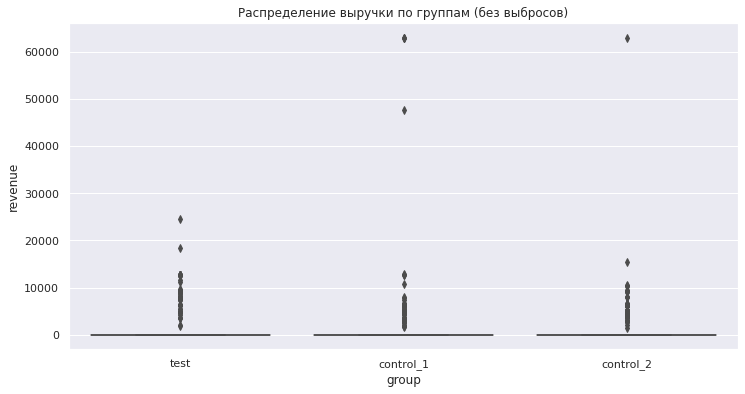

In [10]:
sns.boxplot(x='group', y='revenue', data=users_clean)
plt.title('Распределение выручки по группам (без выбросов)')
plt.show()

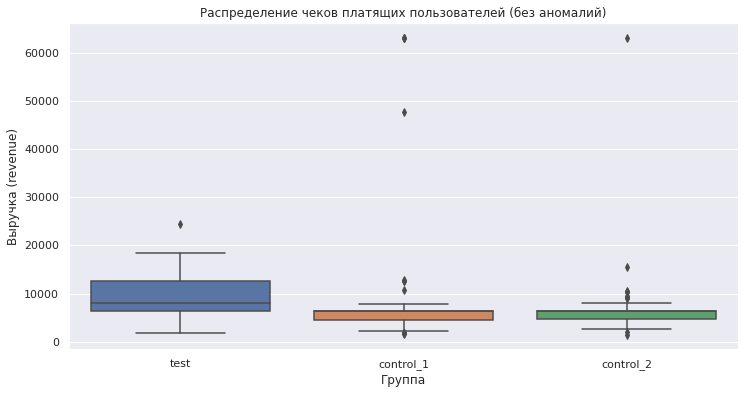

In [11]:
# Фильтруем только платящих пользователей для наглядности
paying_clean = users_clean[users_clean['revenue'] > 0]

sns.boxplot(x='group', y='revenue', data=paying_clean)
plt.title('Распределение чеков платящих пользователей (без аномалий)')
plt.ylabel('Выручка (revenue)')
plt.xlabel('Группа')
plt.show()

### Итоговое заключение по эксперименту

1. **Статистическая значимость (CR):** Обнаружено статистически значимое снижение конверсии (CR) в тестовой группе по сравнению с контрольной (**1.38%** против **2.06%**, p-value = **0.0195**). Это критический показатель: повышение цены отпугнуло значительную часть потенциальных покупателей.
2. **Влияние на доход (ARPU и ARPPU):** Несмотря на то, что средний чек платящего пользователя (ARPPU) в тесте вырос за счет новой цены, этого роста не хватило, чтобы компенсировать падение конверсии. Различия в ARPU между группами статистически не значимы (p-value = **0.9595**).
3. **Влияние выбросов:** Анализ показал, что "успех" теста на сырых данных держался на нескольких аномально крупных платежах ("китах"). После удаления выбросов ARPU в тесте упал до **115.61**, в то время как в контроле остался на уровне **166.09**.
4. **Бизнес-эффект:** Повышение стоимости подписки premium_no_trial привело к значимому оттоку платящих пользователей, при этом не обеспечив статистически подтвержденного роста общей выручки.

**Рекомендация:** Отклонить внедрение новой цены. Эксперимент признан неудачным, так как негативный эффект от падения конверсии превышает выгоду от роста среднего чека.